In [37]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [38]:
df = pd.read_csv(r"C:\Users\hema8\OneDrive\Desktop\High cloud airlines project\airlines dataset cleaned.csv")

In [39]:
df.head()

,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,...,Inflight_entertainment,On_board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,...,5,5,5,5,2,5,5,50,44,satisfied
1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,...,4,4,4,4,3,4,5,0,0,satisfied
2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,...,2,4,1,3,2,2,2,0,0,neutral or dissatisfied
3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,...,1,1,1,1,3,1,4,0,6,satisfied
4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,...,2,2,2,2,4,2,4,0,20,satisfied


In [40]:
df.shape

(25974, 24)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25974 entries, 0 to 25973
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   id                                 25974 non-null  int64
 1   Gender                             25974 non-null  str  
 2   Customer_Type                      25974 non-null  str  
 3   Age                                25974 non-null  int64
 4   Type_of_Travel                     25974 non-null  str  
 5   Class                              25974 non-null  str  
 6   Flight_Distance                    25974 non-null  int64
 7   Inflight_wifi_service              25974 non-null  int64
 8   Departure/Arrival_time_convenient  25974 non-null  int64
 9   Ease_of_Online_booking             25974 non-null  int64
 10  Gate_location                      25974 non-null  int64
 11  Food_and_drink                     25974 non-null  int64
 12  Online_boarding              

In [42]:
print(df.columns)

Index(['id', 'Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class',
       'Flight_Distance', 'Inflight_wifi_service',
       'Departure/Arrival_time_convenient', 'Ease_of_Online_booking',
       'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort',
       'Inflight_entertainment', 'On_board_service', 'Leg_room_service',
       'Baggage_handling', 'Checkin_service', 'Inflight_service',
       'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes',
       'satisfaction'],
      dtype='str')


In [43]:
# Features (Independent Variables)
X = df.drop(['id', 'satisfaction'], axis=1)

# Target (Dependent Variable)
y = df['satisfaction']

In [44]:
print(X.head())

   Gender      Customer_Type  Age   Type_of_Travel     Class  Flight_Distance  \
0  Female     Loyal Customer   52  Business travel       Eco              160   
1  Female     Loyal Customer   36  Business travel  Business             2863   
2    Male  disloyal Customer   20  Business travel       Eco              192   
3    Male     Loyal Customer   44  Business travel  Business             3377   
4  Female     Loyal Customer   49  Business travel       Eco             1182   

   Inflight_wifi_service  Departure/Arrival_time_convenient  \
0                      5                                  4   
1                      1                                  1   
2                      2                                  0   
3                      0                                  0   
4                      2                                  3   

   Ease_of_Online_booking  Gate_location  ...  Seat_comfort  \
0                       3              4  ...             3   
1       

In [45]:
print(y.head())


0                  satisfied
1                  satisfied
2    neutral or dissatisfied
3                  satisfied
4                  satisfied
Name: satisfaction, dtype: str


In [46]:
print(X.dtypes)

Gender                                 str
Customer_Type                          str
Age                                  int64
Type_of_Travel                         str
Class                                  str
Flight_Distance                      int64
Inflight_wifi_service                int64
Departure/Arrival_time_convenient    int64
Ease_of_Online_booking               int64
Gate_location                        int64
Food_and_drink                       int64
Online_boarding                      int64
Seat_comfort                         int64
Inflight_entertainment               int64
On_board_service                     int64
Leg_room_service                     int64
Baggage_handling                     int64
Checkin_service                      int64
Inflight_service                     int64
Cleanliness                          int64
Departure_Delay_in_Minutes           int64
Arrival_Delay_in_Minutes             int64
dtype: object


In [47]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode categorical columns
X['Gender'] = le.fit_transform(X['Gender'])
X['Customer_Type'] = le.fit_transform(X['Customer_Type'])
X['Type_of_Travel'] = le.fit_transform(X['Type_of_Travel'])
X['Class'] = le.fit_transform(X['Class'])

# Encode target variable
y = le.fit_transform(y)

In [48]:
X.head()

,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,Gate_location,...,Seat_comfort,Inflight_entertainment,On_board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes
0,0,0,52,0,1,160,5,4,3,4,...,3,5,5,5,5,2,5,5,50,44
1,0,0,36,0,0,2863,1,1,3,1,...,5,4,4,4,4,3,4,5,0,0
2,1,1,20,0,1,192,2,0,2,4,...,2,2,4,1,3,2,2,2,0,0
3,1,0,44,0,0,3377,0,0,0,2,...,4,1,1,1,1,3,1,4,0,6
4,0,0,49,0,1,1182,2,3,4,3,...,2,2,2,2,2,4,2,4,0,20


In [49]:
print(y[:10])

[1 1 0 1 1 1 1 1 1 1]


In [50]:
# Import train_test_split function
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%)
# X = Input features
# y = Target variable (Passenger Satisfaction)
# test_size = 0.20 means 20% of the data is used for testing
# random_state = 42 ensures the split is the same every time you run the code

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [51]:
# Display the number of rows and columns in the training and testing datasets

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (20779, 22)
Testing Data Shape: (5195, 22)


In [52]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Scale the training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale the testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [53]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [54]:
# Predict passenger satisfaction
y_pred = model.predict(X_test_scaled)

# Display first 10 predictions
print(y_pred[:10])

[1 1 0 0 0 1 1 0 1 0]


In [55]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Display model accuracy
print("Accuracy:", accuracy)

# Display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display precision, recall and F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8650625601539942

Confusion Matrix:
[[2617  298]
 [ 403 1877]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.88      2915
           1       0.86      0.82      0.84      2280

    accuracy                           0.87      5195
   macro avg       0.86      0.86      0.86      5195
weighted avg       0.86      0.87      0.86      5195



In [56]:
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
# random_state=42 ensures the results are reproducible
dt_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model
dt_model.fit(X_train, y_train)

# Predict passenger satisfaction
dt_pred = dt_model.predict(X_test)

In [57]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)

# Display results
print("Decision Tree Accuracy:", dt_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9345524542829644

Confusion Matrix:
[[2742  173]
 [ 167 2113]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2915
           1       0.92      0.93      0.93      2280

    accuracy                           0.93      5195
   macro avg       0.93      0.93      0.93      5195
weighted avg       0.93      0.93      0.93      5195



In [58]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
# n_estimators=100 means the model will build 100 decision trees
# random_state=42 ensures reproducible results

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [59]:
# Train the Random Forest model
rf_model.fit(X_train, y_train)
# Predict passenger satisfaction using the testing dataset
rf_pred = rf_model.predict(X_test)

In [60]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate model accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

# Display accuracy
print("Random Forest Accuracy:", rf_accuracy)

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9580365736284889

Confusion Matrix:
[[2831   84]
 [ 134 2146]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2915
           1       0.96      0.94      0.95      2280

    accuracy                           0.96      5195
   macro avg       0.96      0.96      0.96      5195
weighted avg       0.96      0.96      0.96      5195



In [61]:
# Import K-Nearest Neighbors Classifier
from sklearn.neighbors import KNeighborsClassifier


In [62]:
# Create the KNN model
# n_neighbors=5 means the model looks at the 5 nearest neighbors

knn_model = KNeighborsClassifier(n_neighbors=5)

In [63]:
# Train the model using the scaled training data

knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [64]:
# Predict passenger satisfaction

knn_pred = knn_model.predict(X_test_scaled)

In [65]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.917228103946102

Confusion Matrix:
[[2791  124]
 [ 306 1974]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      2915
           1       0.94      0.87      0.90      2280

    accuracy                           0.92      5195
   macro avg       0.92      0.91      0.92      5195
weighted avg       0.92      0.92      0.92      5195



In [66]:
# Import Gaussian Naïve Bayes Classifier
from sklearn.naive_bayes import GaussianNB

In [67]:
# Create Gaussian Naïve Bayes model
nb_model = GaussianNB()

In [68]:
# Train the model using the training data

nb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[11656., 9123.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.56,0.44]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.001005
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](22,)","['Gender','Customer_Type','Age',...,'Cleanliness', 'Departure_Delay_in_Minutes','Arrival_Delay_in_Minutes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,22
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 22)","[[ 0.49, 0.25,38.01,..., 2.92,16.11,16.73], [ 0.49, 0.11,41.6 ,..., 3.76,12.18,12.19]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 22)","[[ 0.25, 0.19, 271.49,..., 1.76,1658.32,1667.74], [ 0.25, 0.1 , 166.95,..., 1.31,1149.01,1130.34]]"


In [69]:
# Predict passenger satisfaction

nb_pred = nb_model.predict(X_test)

In [70]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
nb_accuracy = accuracy_score(y_test, nb_pred)

# Display accuracy
print("Naïve Bayes Accuracy:", nb_accuracy)

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nb_pred))

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

Naïve Bayes Accuracy: 0.8510105871029836

Confusion Matrix:
[[2589  326]
 [ 448 1832]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      2915
           1       0.85      0.80      0.83      2280

    accuracy                           0.85      5195
   macro avg       0.85      0.85      0.85      5195
weighted avg       0.85      0.85      0.85      5195



In [71]:
# Import Support Vector Machine Classifier
from sklearn.svm import SVC

In [74]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create SVM model
svm_model = SVC(
    kernel='rbf',
    random_state=42
)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Predict passenger satisfaction
svm_pred = svm_model.predict(X_test_scaled)

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

SVM Accuracy: 0.9484119345524543

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      2915
           1       0.95      0.93      0.94      2280

    accuracy                           0.95      5195
   macro avg       0.95      0.95      0.95      5195
weighted avg       0.95      0.95      0.95      5195


Confusion Matrix:
[[2807  108]
 [ 160 2120]]


In [75]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, svm_pred)

# Display accuracy
print("SVM Accuracy:", svm_accuracy)

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9484119345524543

Confusion Matrix:
[[2807  108]
 [ 160 2120]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      2915
           1       0.95      0.93      0.94      2280

    accuracy                           0.95      5195
   macro avg       0.95      0.95      0.95      5195
weighted avg       0.95      0.95      0.95      5195



In [76]:
import sys
print(sys.version)

3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]


In [77]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [78]:
# Import XGBoost Classifier
from xgboost import XGBClassifier

In [79]:
# Create XGBoost model

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

In [80]:
# Train the XGBoost model

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [81]:
# Predict passenger satisfaction

xgb_pred = xgb_model.predict(X_test)

In [82]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9599615014436959

Confusion Matrix:
[[2832   83]
 [ 125 2155]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      2915
           1       0.96      0.95      0.95      2280

    accuracy                           0.96      5195
   macro avg       0.96      0.96      0.96      5195
weighted avg       0.96      0.96      0.96      5195



In [83]:
# Create a DataFrame for feature importance
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display the results
print(feature_importance)

                              Feature  Importance
11                    Online_boarding    0.173491
6               Inflight_wifi_service    0.127967
3                      Type_of_Travel    0.102697
4                               Class    0.087658
13             Inflight_entertainment    0.063985
12                       Seat_comfort    0.043551
5                     Flight_Distance    0.039554
8              Ease_of_Online_booking    0.039536
15                   Leg_room_service    0.039383
2                                 Age    0.035044
1                       Customer_Type    0.034015
14                   On_board_service    0.029387
19                        Cleanliness    0.027724
17                    Checkin_service    0.027334
18                   Inflight_service    0.025302
16                   Baggage_handling    0.024928
9                       Gate_location    0.016815
7   Departure/Arrival_time_convenient    0.016787
21           Arrival_Delay_in_Minutes    0.013831


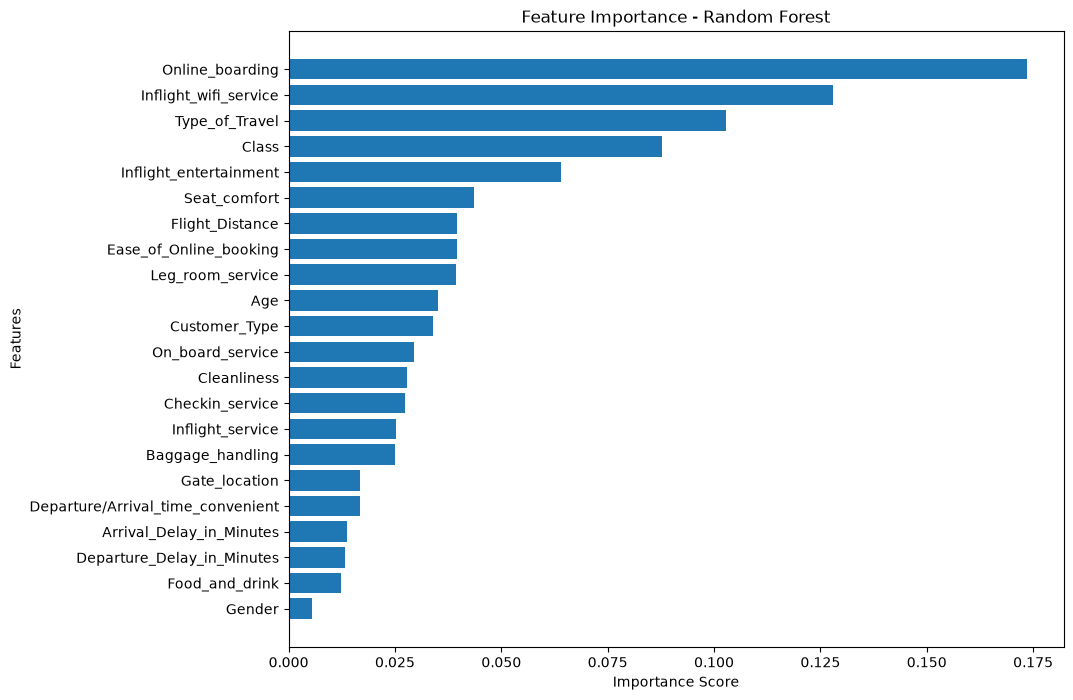

In [84]:
import matplotlib.pyplot as plt

# Plot Feature Importance
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.show()

In [85]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [86]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [87]:
# Create Random Forest model

rf = RandomForestClassifier(random_state=42)

# Create Grid Search

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [88]:
rf = RandomForestClassifier(random_state=42)

In [89]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [90]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ve

In [91]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Accuracy:
0.9531738260777916


In [92]:
best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score

print("Tuned Random Forest Accuracy:")
print(accuracy_score(y_test, best_pred))

Tuned Random Forest Accuracy:
0.9570741097208855


In [93]:
import joblib

joblib.dump(xgb_model, "xgboost_airline_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [94]:
joblib.dump(scaler, "scaler.pkl")

print("✅ Scaler saved successfully!")

✅ Scaler saved successfully!


In [95]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [96]:
import os
print(os.listdir())

['.anaconda', '.android', '.conda', '.condarc', '.continuum', '.dotnet', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.spyder-py3', '.streamlit', '.templateengine', 'Airline_Passenger_Satisfaction_Prediction.ipynb', 'AI_lab_MCSL106.ipynb', 'anaconda3', 'AndroidStudioProjects', 'AppData', 'Application Data', 'assignmentai.ipynb', 'BI_assignment.ipynb', 'Contacts', 'Cookies', 'COVID dataset.csv', 'Documents', 'Downloads', 'Favorites', 'highcloudairlines.ipynb', 'Iris.csv', 'Jedi', 'Links', 'Local Settings', 'MCSL106 DataSet.zip', 'Mental Health dataset1.csv', 'mental_health.ipynb', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{b71a8020-d88f-11ef-af42-e379edbd9325}.TM.blf', 'NTUSER.DAT{b71a8020-d88f-11ef-af42-e379edbd9325}.TM.blf.cnpf', 'NTUSER.DAT{b71a8020-d88f-11ef-af42-e379edbd9325}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{b71a8020-d88f-11ef-af42-e379edbd9325}.TMContainer000000000000000

In [98]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [100]:
import streamlit as st

print(st.__version__)

1.58.0


In [102]:
print(df.drop('satisfaction', axis=1).columns.tolist())

['id', 'Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class', 'Flight_Distance', 'Inflight_wifi_service', 'Departure/Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On_board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes']
